In [3]:
import numpy as np
import matplotlib.pyplot as plt

#Step 1: Generarte some sample data
#Creating data points that roughly follow a quadratic curve

np.random.seed(0)
x = np.linspace(-5, 5, 50) # 50 points between -5 and 5
y = 2 * x**2 + 3 * x + np.random.randn(50) * 10 # y = 2x^2 + 3x + some noise

In [4]:
# Step 2: Polynomial fitting using NumPy's polyfit
# Fit a 2nd degree polynomial to the data

degree = 2 # Degree of the polynomial
coefficients = np.polyfit(x, y, degree)

# Print the polynomial coefficients

print("Polynomial Coefficients: ", coefficients)

# Step 3: Use the coefficients to predict y-values (polynomial function)
# Generate polynomial function based on the coefficients

polynomial = np.poly1d(coefficients)

Polynomial Coefficients:  [2.09218103 1.58837751 0.60606342]


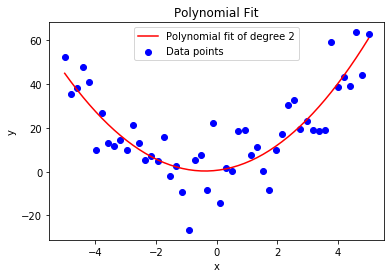

In [5]:
# Generate predicted y-values based on the fitted polynomial

y_pred = polynomial(x)

# Step 4: Plotting the results

plt.scatter(x, y, color='blue', label='Data points') # Original data points
plt.plot(x, y_pred, color='red', label=f'Polynomial fit of degree {degree}')

# Fitted curve

plt.title('Polynomial Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [6]:
# Mean Squared Error (MSE)

mse = np.mean((y - y_pred)**2)
print(f'Mean Squared Error: {mse:.4f}')

# R-squared value

ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_pred)**2)

r_squared = 1 - (ss_res / ss_total)

print(f'R-squared: {r_squared:.4f}')

Mean Squared Error: 108.8860
R-squared: 0.7236


# Degree 3 -> 15

As the degree increased there was more wiggles in the curve. How well does our curve fit the data points?

In [11]:
# Step 2: Polynomial fitting using NumPy's polyfit
# Fit a 2nd degree polynomial to the data

degree = 15 # Degree of the polynomial
coefficients = np.polyfit(x, y, degree)

# Print the polynomial coefficients

print("Polynomial Coefficients: ", coefficients)

# Step 3: Use the coefficients to predict y-values (polynomial function)
# Generate polynomial function based on the coefficients

polynomial = np.poly1d(coefficients)

Polynomial Coefficients:  [-1.74771266e-06  9.38973299e-07  1.61353605e-04 -3.96195404e-05
 -5.97939499e-03 -3.17802055e-04  1.13849286e-01  3.83010603e-02
 -1.18388915e+00 -6.63600408e-01  6.58472724e+00  4.30302606e+00
 -1.76197496e+01 -7.33866097e+00  1.85416072e+01  4.11389585e+00]


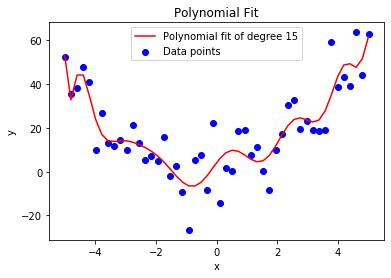

In [12]:
# Generate predicted y-values based on the fitted polynomial

y_pred = polynomial(x)

# Step 4: Plotting the results

plt.scatter(x, y, color='blue', label='Data points') # Original data points
plt.plot(x, y_pred, color='red', label=f'Polynomial fit of degree {degree}')

# Fitted curve

plt.title('Polynomial Fit')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

In [13]:
# Mean Squared Error (MSE)

mse = np.mean((y - y_pred)**2)
print(f'Mean Squared Error: {mse:.4f}')

# R-squared value

ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_pred)**2)

r_squared = 1 - (ss_res / ss_total)

print(f'R-squared: {r_squared:.4f}')

Mean Squared Error: 86.1701
R-squared: 0.7812


## I put this into Copilot:

# Challenge A: Linear Least Squares vs. Polynomial Fit

- Revisit your challenge from last Least Squares where you evaluated the Least Squares method against using random vectors of X and Y.
- Fit the data points to Least Squares and Polyfit - start with a cubic polynomial - methods
- We'll need to see the line and the polynomial
- Evaluate MSE and R-Squared for each method.
- Have your code evaluate which is the better which method is better fit

## It gave me this response:

=== Linear Least Squares ===
Slope: 2.0410, Intercept: 0.9199
MSE: 0.3503
R²:  0.5027

=== Cubic Polynomial Fit ===
Coefficients: [-3.0628312   4.46214323  0.3446083   1.04660646]
MSE: 0.3467
R²:  0.5079

>>> The cubic polynomial provides a better fit.


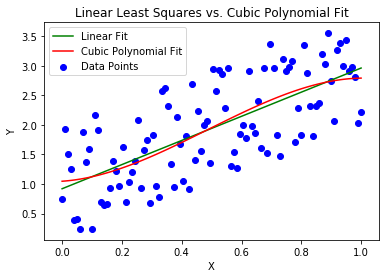

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Step 1: Generate random linear data (same as Ch9)
# ---------------------------------------------------------
np.random.seed(42)

# True underlying linear model
m_true = 2.0
b_true = 1.0

# Generate X and Y with noise
X = np.linspace(0, 1, 100)
noise = np.random.uniform(-1, 1, size=X.shape)
Y = m_true * X + b_true + noise

# ---------------------------------------------------------
# Step 2: Manual Linear Least Squares
# ---------------------------------------------------------
X_mean = np.mean(X)
Y_mean = np.mean(Y)

m_manual = np.sum((X - X_mean) * (Y - Y_mean)) / np.sum((X - X_mean)**2)
b_manual = Y_mean - m_manual * X_mean

Y_pred_linear = m_manual * X + b_manual

# ---------------------------------------------------------
# Step 3: Polynomial Fit (Cubic)
# ---------------------------------------------------------
degree = 3
coeffs_poly = np.polyfit(X, Y, degree)
poly_model = np.poly1d(coeffs_poly)
Y_pred_poly = poly_model(X)

# ---------------------------------------------------------
# Step 4: Compute MSE and R² for both models
# ---------------------------------------------------------
def compute_metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred)**2)
    ss_total = np.sum((y_true - np.mean(y_true))**2)
    ss_res = np.sum((y_true - y_pred)**2)
    r2 = 1 - ss_res / ss_total
    return mse, r2

mse_linear, r2_linear = compute_metrics(Y, Y_pred_linear)
mse_poly, r2_poly = compute_metrics(Y, Y_pred_poly)

print("=== Linear Least Squares ===")
print(f"Slope: {m_manual:.4f}, Intercept: {b_manual:.4f}")
print(f"MSE: {mse_linear:.4f}")
print(f"R²:  {r2_linear:.4f}\n")

print("=== Cubic Polynomial Fit ===")
print(f"Coefficients: {coeffs_poly}")
print(f"MSE: {mse_poly:.4f}")
print(f"R²:  {r2_poly:.4f}\n")

# ---------------------------------------------------------
# Step 5: Decide which model is better
# ---------------------------------------------------------
if r2_poly > r2_linear:
    print(">>> The cubic polynomial provides a better fit.")
else:
    print(">>> The linear least squares model provides a better fit.")

# ---------------------------------------------------------
# Step 6: Plot both fits
# ---------------------------------------------------------
plt.scatter(X, Y, color='blue', label='Data Points')
plt.plot(X, Y_pred_linear, color='green', label='Linear Fit')
plt.plot(X, Y_pred_poly, color='red', label='Cubic Polynomial Fit')

plt.title("Linear Least Squares vs. Cubic Polynomial Fit")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

## I put this into Copilot:

# Challenge B: Linear Least Squares vs Polynomial fit

- Revisit your challenge from last Least Squares where you evaluated the Least Squares method against using random vectors of X and Y.
- Fit the data points to Least Squares and Polyfit - start with a cubic polynomial - methods
- crank the polynomial up 1 degree at a time until it blatantly overfits
- crank the polynomial down 1 dress at a time (keep it > 0) until it underfits
- evaluate MSE and R-Squared for each run

## It gave me this response:

=== Linear Least Squares ===
Slope: 2.0410, Intercept: 0.9199

=== Polynomial Sweep Results ===
Degree  1 | MSE = 0.3503 | R² = 0.5027
Degree  2 | MSE = 0.3502 | R² = 0.5029
Degree  3 | MSE = 0.3467 | R² = 0.5079
Degree  4 | MSE = 0.3463 | R² = 0.5085
Degree  5 | MSE = 0.3400 | R² = 0.5174
Degree  6 | MSE = 0.3341 | R² = 0.5257
Degree  7 | MSE = 0.3316 | R² = 0.5292
Degree  8 | MSE = 0.3306 | R² = 0.5307
Degree  9 | MSE = 0.3273 | R² = 0.5354
Degree 10 | MSE = 0.3267 | R² = 0.5363
Degree 11 | MSE = 0.3267 | R² = 0.5363
Degree 12 | MSE = 0.3229 | R² = 0.5416
Degree 13 | MSE = 0.3158 | R² = 0.5517
Degree 14 | MSE = 0.3013 | R² = 0.5723
Degree 15 | MSE = 0.2996 | R² = 0.5748


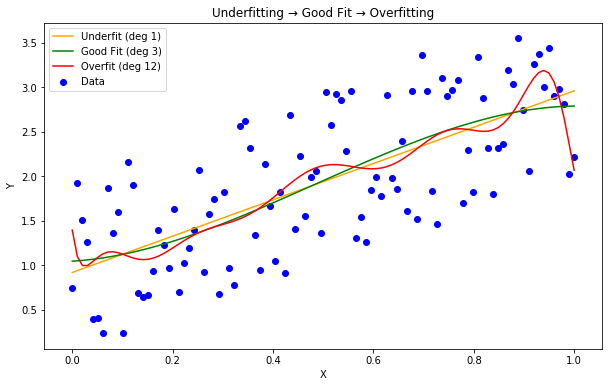

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Step 1: Generate random linear data (same as Challenge A)
# ---------------------------------------------------------
np.random.seed(42)

m_true = 2.0
b_true = 1.0

X = np.linspace(0, 1, 100)
noise = np.random.uniform(-1, 1, size=X.shape)
Y = m_true * X + b_true + noise

# ---------------------------------------------------------
# Step 2: Manual Linear Least Squares
# ---------------------------------------------------------
X_mean = np.mean(X)
Y_mean = np.mean(Y)

m_manual = np.sum((X - X_mean) * (Y - Y_mean)) / np.sum((X - X_mean)**2)
b_manual = Y_mean - m_manual * X_mean

Y_pred_linear = m_manual * X + b_manual

# ---------------------------------------------------------
# Step 3: Polynomial Fit Function
# ---------------------------------------------------------
def poly_metrics(degree):
    coeffs = np.polyfit(X, Y, degree)
    model = np.poly1d(coeffs)
    Y_pred = model(X)

    mse = np.mean((Y - Y_pred)**2)
    ss_total = np.sum((Y - np.mean(Y))**2)
    ss_res = np.sum((Y - Y_pred)**2)
    r2 = 1 - ss_res / ss_total

    return coeffs, Y_pred, mse, r2

# ---------------------------------------------------------
# Step 4: Sweep polynomial degrees upward (overfitting)
# ---------------------------------------------------------
max_degree = 15
results = {}

for d in range(1, max_degree + 1):
    coeffs, Yp, mse, r2 = poly_metrics(d)
    results[d] = {"coeffs": coeffs, "mse": mse, "r2": r2}

# ---------------------------------------------------------
# Step 5: Identify underfitting and overfitting
# ---------------------------------------------------------
# Underfitting: low degree → low R², high MSE
# Overfitting: high degree → R² artificially high, unstable coefficients, oscillations

print("=== Linear Least Squares ===")
print(f"Slope: {m_manual:.4f}, Intercept: {b_manual:.4f}")
print()

print("=== Polynomial Sweep Results ===")
for d in results:
    print(f"Degree {d:2d} | MSE = {results[d]['mse']:.4f} | R² = {results[d]['r2']:.4f}")

# ---------------------------------------------------------
# Step 6: Plot representative cases
# ---------------------------------------------------------
# Choose:
# - degree 1 (underfit)
# - degree 3 (reasonable)
# - degree 10+ (overfit)

deg_under = 1
deg_good = 3
deg_over = 12

Y_under = np.poly1d(results[deg_under]["coeffs"])(X)
Y_good = np.poly1d(results[deg_good]["coeffs"])(X)
Y_over = np.poly1d(results[deg_over]["coeffs"])(X)

plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='blue', label='Data')

plt.plot(X, Y_under, color='orange', label=f'Underfit (deg {deg_under})')
plt.plot(X, Y_good, color='green', label=f'Good Fit (deg {deg_good})')
plt.plot(X, Y_over, color='red', label=f'Overfit (deg {deg_over})')

plt.title("Underfitting → Good Fit → Overfitting")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

# Vandermonde Matrix in Python

In [16]:
import numpy as np

# Example data points
x = np.array([1, 2, 3])

# Create Vandermonde matrix for a polynomial of degree 2
degree = 2
V = np.vander(x, N=degree+1, increasing=True)

print(V)

[[1 1 1]
 [1 2 4]
 [1 3 9]]


## I put this prompt into Copilot:

# Challenge C - The Vandermonde

- Code the polynomial fit using the Vandermonde Matrix against the same data points as in part A

## This is what it gave me:

=== Vandermonde Fit ===
Coefficients: [ 1.04660646  0.3446083   4.46214323 -3.0628312 ]
MSE: 0.3467, R²: 0.5079

=== NumPy Polyfit ===
Coefficients: [-3.0628312   4.46214323  0.3446083   1.04660646]
MSE: 0.3467, R²: 0.5079



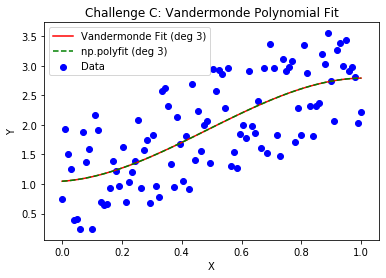

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Step 1: Generate the same random linear data as Challenge A
# ---------------------------------------------------------
np.random.seed(42)

m_true = 2.0
b_true = 1.0

X = np.linspace(0, 1, 100)
noise = np.random.uniform(-1, 1, size=X.shape)
Y = m_true * X + b_true + noise

# ---------------------------------------------------------
# Step 2: Build Vandermonde matrix
# ---------------------------------------------------------
def vandermonde_fit(x, y, degree):
    # Create Vandermonde matrix (increasing powers)
    V = np.vander(x, N=degree+1, increasing=True)

    # Solve normal equation: (VᵀV)c = Vᵀy
    coeffs = np.linalg.solve(V.T @ V, V.T @ y)

    return coeffs

# ---------------------------------------------------------
# Step 3: Fit a cubic polynomial using Vandermonde
# ---------------------------------------------------------
degree = 3
coeffs_vander = vandermonde_fit(X, Y, degree)

# Build polynomial function
poly_vander = np.poly1d(coeffs_vander[::-1])  # reverse for np.poly1d order
Y_pred_vander = poly_vander(X)

# ---------------------------------------------------------
# Step 4: Compare with numpy polyfit
# ---------------------------------------------------------
coeffs_np = np.polyfit(X, Y, degree)
poly_np = np.poly1d(coeffs_np)
Y_pred_np = poly_np(X)

# ---------------------------------------------------------
# Step 5: Compute MSE and R²
# ---------------------------------------------------------
def metrics(y, y_pred):
    mse = np.mean((y - y_pred)**2)
    ss_total = np.sum((y - np.mean(y))**2)
    ss_res = np.sum((y - y_pred)**2)
    r2 = 1 - ss_res / ss_total
    return mse, r2

mse_v, r2_v = metrics(Y, Y_pred_vander)
mse_np, r2_np = metrics(Y, Y_pred_np)

print("=== Vandermonde Fit ===")
print("Coefficients:", coeffs_vander)
print(f"MSE: {mse_v:.4f}, R²: {r2_v:.4f}\n")

print("=== NumPy Polyfit ===")
print("Coefficients:", coeffs_np)
print(f"MSE: {mse_np:.4f}, R²: {r2_np:.4f}\n")

# ---------------------------------------------------------
# Step 6: Plot the results
# ---------------------------------------------------------
plt.scatter(X, Y, color='blue', label='Data')
plt.plot(X, Y_pred_vander, color='red', label='Vandermonde Fit (deg 3)')
plt.plot(X, Y_pred_np, color='green', linestyle='--', label='np.polyfit (deg 3)')

plt.title("Challenge C: Vandermonde Polynomial Fit")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()